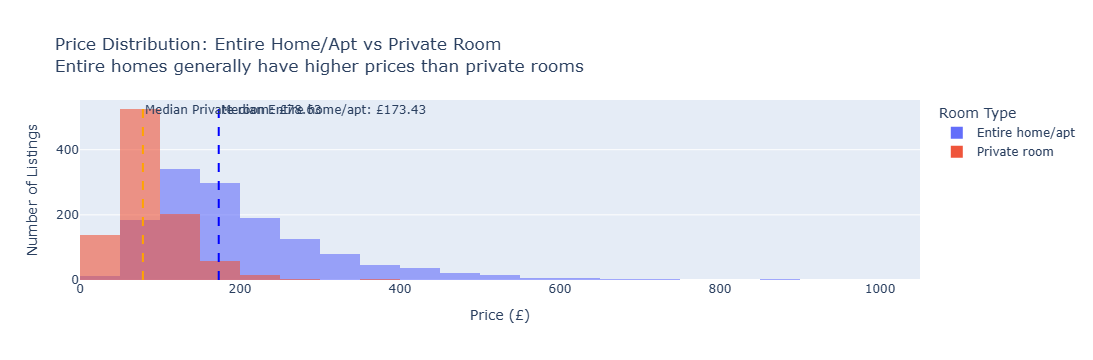

In [2]:
# Task 1 - Histogram: price by room type (overlapping distributions)

import pandas as pd
import plotly.express as px

# Load dataset
df_cap = pd.read_csv("airbnb_london.csv")

# Exclude Shared room, keep only two room types
df_hist = df_cap[
    df_cap['room_type'].isin(['Entire home/apt', 'Private room'])
].copy()

# Median prices for each room type
median_entire = df_hist.loc[
    df_hist['room_type'] == 'Entire home/apt',
    'price'
].median()

median_private = df_hist.loc[
    df_hist['room_type'] == 'Private room',
    'price'
].median()

# Create overlapping histogram
fig = px.histogram(
    df_hist,
    x='price',
    color='room_type',
    nbins=50,
    opacity=0.6,
    title="Price Distribution: Entire Home/Apt vs Private Room<br>"
          "Entire homes generally have higher prices than private rooms"
)

# Overlay distributions
fig.update_layout(
    barmode='overlay',
    xaxis_title="Price (£)",
    yaxis_title="Number of Listings",
    legend_title="Room Type"
)

# Add median lines
fig.add_vline(
    x=median_entire,
    line_dash="dash",
    line_color="blue",
    annotation_text=f"Median Entire home/apt: £{median_entire:.2f}"
)

fig.add_vline(
    x=median_private,
    line_dash="dash",
    line_color="orange",
    annotation_text=f"Median Private room: £{median_private:.2f}"
)

fig.show()

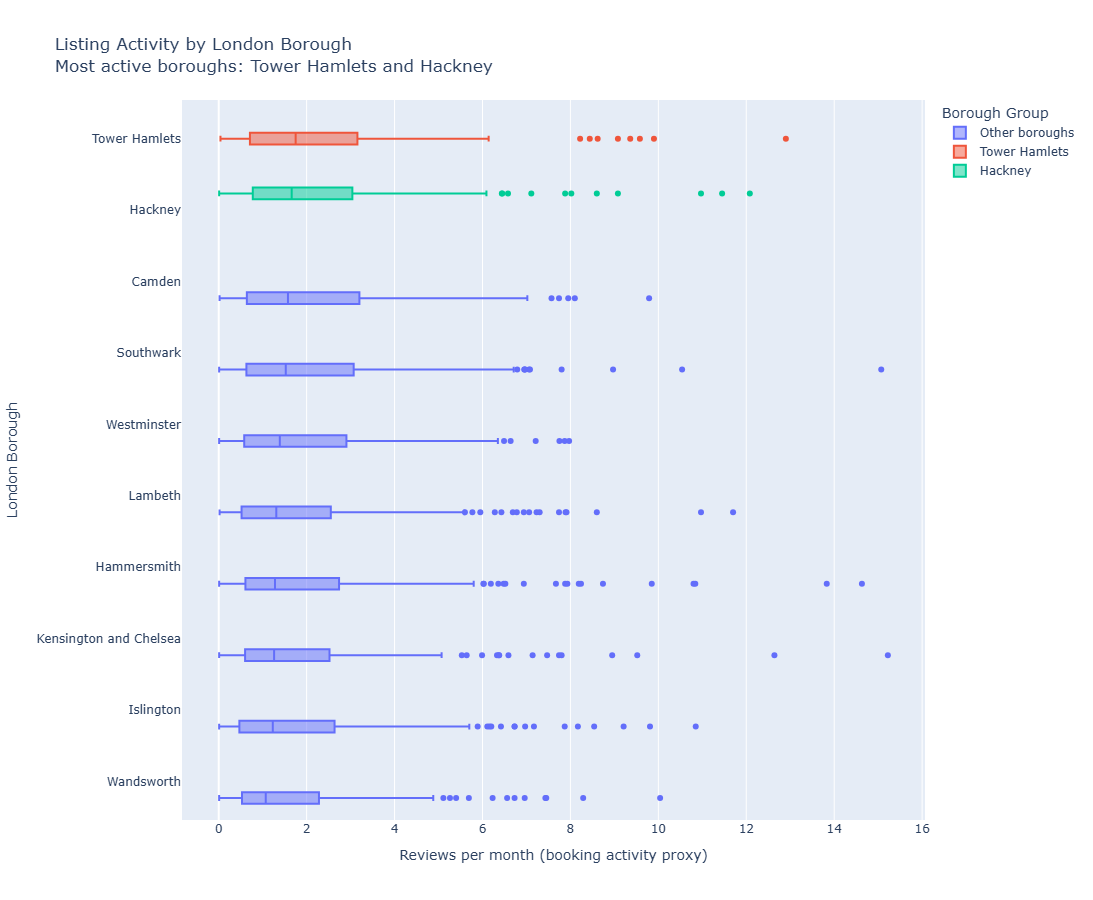

In [3]:
# Task 2 - Box plot: listing activity by borough

import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_csv("airbnb_london.csv")

# Remove listings with zero reviews
df_box = df[df['reviews_per_month'] > 0].copy()

# Calculate median activity by borough
borough_order = (
    df_box.groupby('neighbourhood')['reviews_per_month']
    .median()
    .sort_values(ascending=False)
    .index
)

# Find top 2 busiest boroughs
top_two = borough_order[:2].tolist()

# Create highlight column
df_box['highlight'] = df_box['neighbourhood'].apply(
    lambda x: x if x in top_two else "Other boroughs"
)

# Box plot
fig = px.box(
    df_box,
    y="neighbourhood",
    x="reviews_per_month",
    color="highlight",
    category_orders={"neighbourhood": borough_order},
    points="outliers",
    orientation="h",
    title=f"Listing Activity by London Borough<br>"
          f"Most active boroughs: {top_two[0]} and {top_two[1]}"
)

# Layout adjustments
fig.update_layout(
    xaxis_title="Reviews per month (booking activity proxy)",
    yaxis_title="London Borough",
    legend_title="Borough Group",
    height=900
)

fig.show()